In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
from datetime import datetime, timedelta

# 한글 폰트 설정
font_prop = fm.FontProperties(fname=r'C:\Windows\Fonts\malgun.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
TASK_DIR = os.path.dirname(BASE_DIR)
RES_DIR  = os.path.join(TASK_DIR, 'resources')
OUT_DIR  = os.path.join(TASK_DIR, 'output')
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')
print(f'수집 기간: {START_DATE} ~ {END_DATE}')

수집 기간: 2025-05-19 ~ 2026-05-19


In [2]:
# yfinance로 5개 종목 1년치 일별 주가 수집
frames = []
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
    df = df[['Close']].reset_index()
    df.columns = ['date', 'close']
    df['ticker'] = ticker
    frames.append(df)

stock_df = pd.concat(frames, ignore_index=True)
print(f'수집 완료: {stock_df.shape[0]}행, 종목={stock_df["ticker"].unique().tolist()}')
stock_df.head()

수집 완료: 1255행, 종목=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']


,date,close,ticker
0,2025-05-19,207.955002,AAPL
1,2025-05-20,206.042587,AAPL
2,2025-05-21,201.291428,AAPL
3,2025-05-22,200.564316,AAPL
4,2025-05-23,194.498398,AAPL


In [3]:
# 데이터 탐색: shape, 결측값, 날짜 범위
print('shape:', stock_df.shape)
print('결측값:\n', stock_df.isnull().sum().to_string())
print('날짜 범위:', stock_df['date'].min(), '~', stock_df['date'].max())
print('종목별 데이터 수:\n', stock_df.groupby('ticker').size().to_string())

shape: (1255, 3)
결측값:
 date      0
close     0
ticker    0
날짜 범위: 2025-05-19 00:00:00 ~ 2026-05-18 00:00:00
종목별 데이터 수:
 ticker
AAPL     251
AMZN     251
GOOGL    251
MSFT     251
TSLA     251


In [4]:
# 종목별 종가 요약 통계 (평균, 최솟값, 최댓값)
summary = stock_df.groupby('ticker')['close'].agg(
    평균='mean', 최솟값='min', 최댓값='max'
).round(2)
print('=== 종목별 종가 요약 통계 ===')
print(summary.to_string())
summary

=== 종목별 종가 요약 통계 ===
            평균     최솟값     최댓값
ticker                        
AAPL    248.04  194.50  300.23
AMZN    227.05  198.79  274.99
GOOGL   268.69  163.41  402.62
MSFT    465.95  356.77  539.83
TSLA    390.89  284.70  489.88


,평균,최솟값,최댓값
ticker,,,
AAPL,248.04,194.50,300.23
AMZN,227.05,198.79,274.99
GOOGL,268.69,163.41,402.62
MSFT,465.95,356.77,539.83
TSLA,390.89,284.70,489.88


In [5]:
# 30일 이동평균 계산 (종목별 날짜순 정렬 후 적용)
stock_df = stock_df.sort_values(['ticker', 'date']).reset_index(drop=True)
stock_df['ma30'] = stock_df.groupby('ticker')['close'].transform(
    lambda x: x.rolling(window=30).mean()
)
print('30일 이동평균 계산 완료')
stock_df[stock_df['ticker'] == 'AAPL'].tail(5)

30일 이동평균 계산 완료


,date,close,ticker,ma30
246,2026-05-12,294.799988,AAPL,270.078544
247,2026-05-13,298.869995,AAPL,271.588997
248,2026-05-14,298.209991,AAPL,273.016174
249,2026-05-15,300.230011,AAPL,274.501026
250,2026-05-18,297.839996,AAPL,275.808303


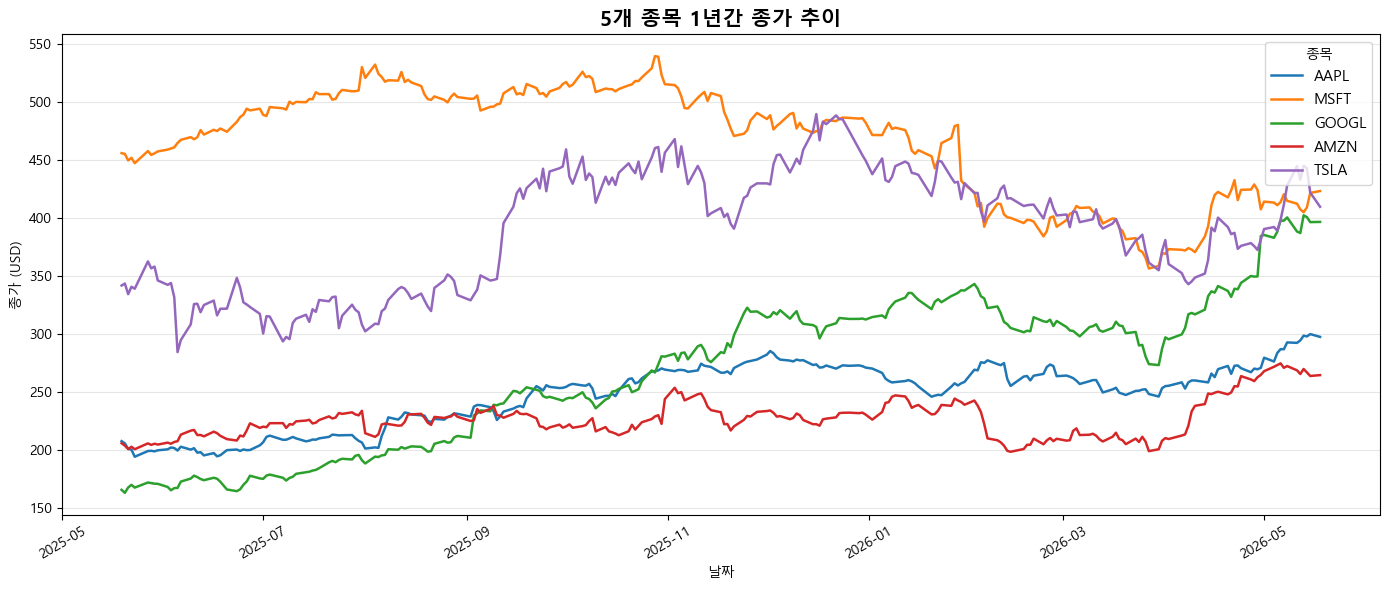

저장: closing_prices.png


In [6]:
# 5개 종목 종가 꺾은선 차트
fig, ax = plt.subplots(figsize=(14, 6))
for ticker in TICKERS:
    df_t = stock_df[stock_df['ticker'] == ticker]
    ax.plot(df_t['date'], df_t['close'], linewidth=1.8, label=ticker)

ax.set_title('5개 종목 1년간 종가 추이', fontsize=15, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('종가 (USD)')
ax.legend(title='종목', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'closing_prices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: closing_prices.png')

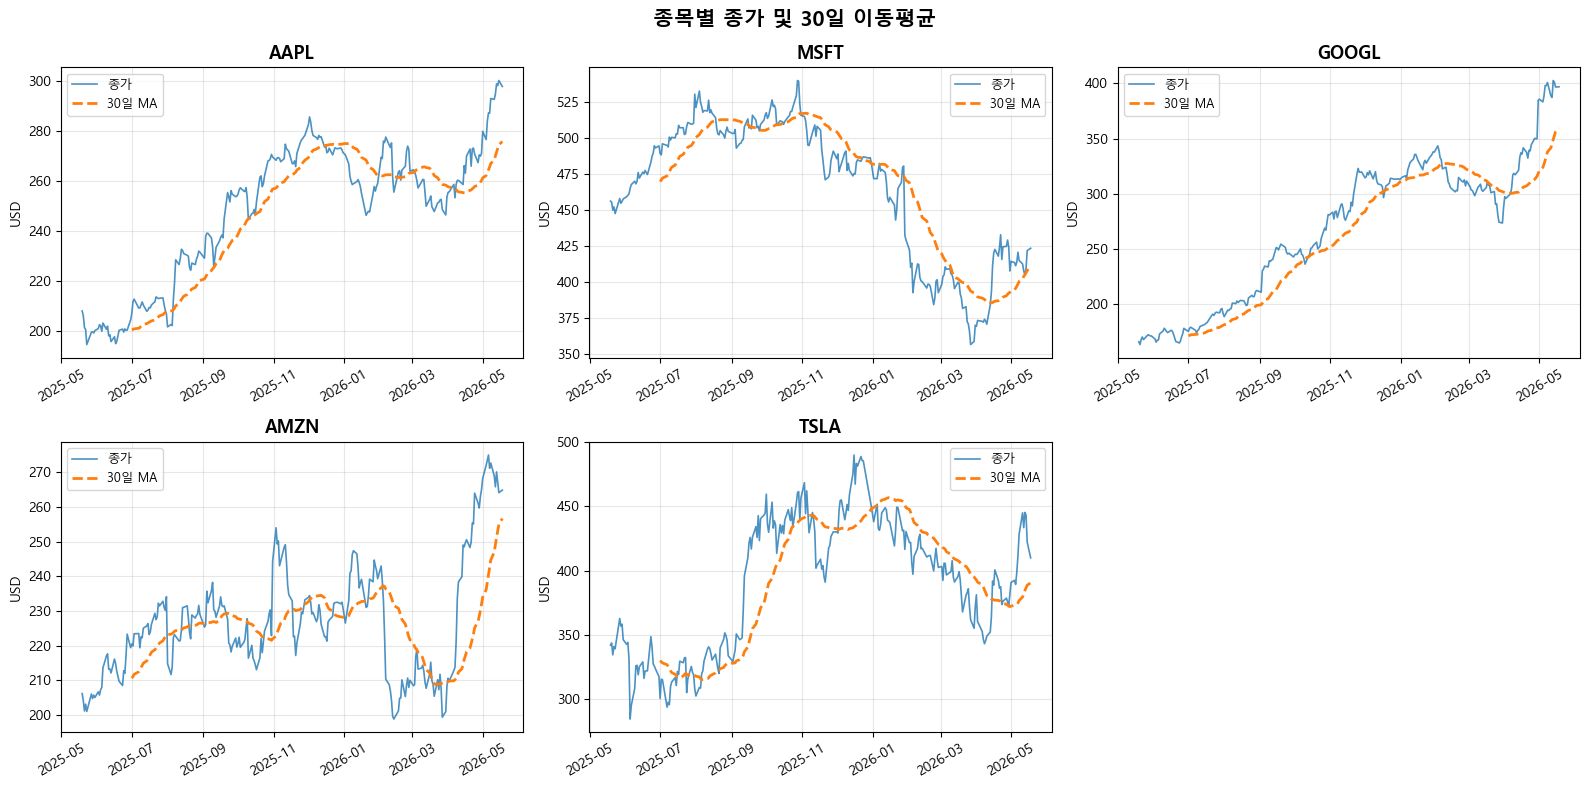

저장: ma30_comparison.png


In [7]:
# 종가 + 30일 이동평균 비교 차트 (종목별 서브플롯)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    df_t = stock_df[stock_df['ticker'] == ticker]
    axes[i].plot(df_t['date'], df_t['close'], linewidth=1.2, label='종가', alpha=0.8)
    axes[i].plot(df_t['date'], df_t['ma30'], linewidth=2, label='30일 MA', linestyle='--')
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('USD')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)  # 빈 칸 숨김
plt.suptitle('종목별 종가 및 30일 이동평균', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ma30_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: ma30_comparison.png')

In [8]:
# 기간 수익률 계산: (마지막 종가 - 첫 종가) / 첫 종가 * 100
returns = {}
for ticker in TICKERS:
    df_t = stock_df[stock_df['ticker'] == ticker].sort_values('date')
    ret = (df_t['close'].iloc[-1] - df_t['close'].iloc[0]) / df_t['close'].iloc[0] * 100
    returns[ticker] = round(ret, 2)

returns_df = pd.DataFrame.from_dict(returns, orient='index', columns=['수익률(%)'])
returns_df = returns_df.sort_values('수익률(%)', ascending=False)
print('=== 기간 수익률 순위 ===')
print(returns_df.to_string())
best = returns_df.index[0]
print(f'\n최고 수익률 종목: {best} ({returns_df.loc[best, "수익률(%)"]:.2f}%)')

=== 기간 수익률 순위 ===
       수익률(%)
GOOGL  139.17
AAPL    43.22
AMZN    28.47
TSLA    19.85
MSFT    -7.16

최고 수익률 종목: GOOGL (139.17%)


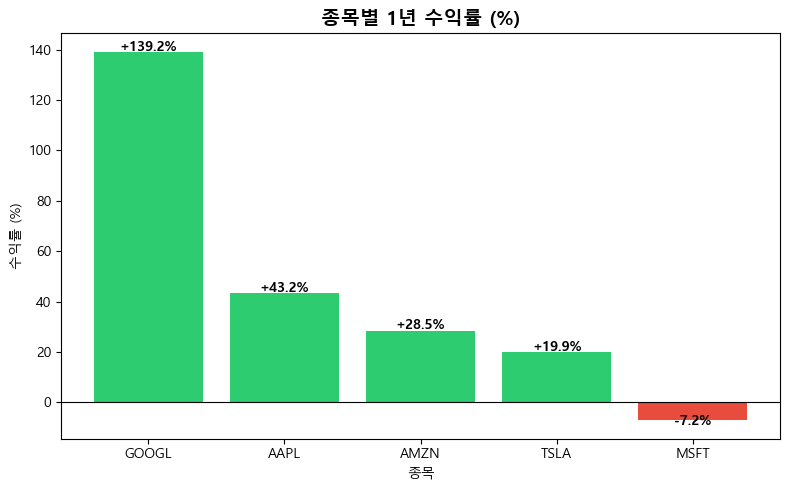

저장: returns_comparison.png


In [9]:
# 수익률 막대 차트
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in returns_df['수익률(%)']]
bars = ax.bar(returns_df.index, returns_df['수익률(%)'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('종목별 1년 수익률 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('종목'); ax.set_ylabel('수익률 (%)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.5 if h >= 0 else -2),
            f'{h:+.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'returns_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: returns_comparison.png')

In [10]:
# 원본 데이터 CSV 저장
csv_path = os.path.join(RES_DIR, 'stock_data.csv')
stock_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: stock_data.csv ({len(stock_df)}행)')
print('모든 작업 완료!')

저장 완료: stock_data.csv (1255행)
모든 작업 완료!
